# Platinum-Palladium -- a quantitative teardown
### Real futures tape * ADF + Engle-Granger * OU half-life * z-score spread * random control * HAC + block-bootstrap inference

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Ratio_mean--reverts%3F: Mixed](https://img.shields.io/badge/Ratio_mean--reverts%3F-Mixed-dab617?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) -- *same seven beats, every claim carrying its standard error.* We test whether the platinum/palladium ratio is stationary, whether the two metals are cointegrated, and whether a z-score spread earns a statistically robust edge over a random-direction control on 16 years of daily futures data.

> **Not investment advice.** Real data: PL=F and PA=F daily futures 2010-01-04 to 2026-05-29 (n = 4,124 / 4,107 bars); offline core runs on a deterministic synthetic OU tape. Methods & sources in [`docs/references.md`](../docs/references.md).
>
> **The `in plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from platinum_palladium import data, strategy as st

PL_TICKER = data.PLATINUM_TICKER   # PL=F
PA_TICKER = data.PALLADIUM_TICKER  # PA=F
AS_OF = pd.Timestamp("2026-05-31")  # drop partial June 2026

def _have_cache():
    return (os.path.exists(data._cache_path(PL_TICKER, data.DEFAULT_CACHE)) and
            os.path.exists(data._cache_path(PA_TICKER, data.DEFAULT_CACHE)))

def load_pair():
    """Cache-first real tape, trimmed to AS_OF; None when offline."""
    try:
        out = data.load_real(fetch=False)
        if out is None:
            return None
        plat, pall = out
        return plat[plat.index <= AS_OF], pall[pall.index <= AS_OF]
    except Exception:
        return None

HAVE_REAL = _have_cache()
print("real daily cache present:", HAVE_REAL)


real daily cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Gross **-101 bps/trade**, HAC *t* = **-0.32** on n = **26 trades**; bootstrap 95% CI [-705, 431] bps straddles zero. |
| **Tradability** | `MIRAGE` | win-rate 73% but skew -2.2 -- a negative-expectancy, fat-left-tail profile. Costs only worsen it. |
| **Ratio mean-reverts?** | `MIXED` | ADF p = 0.011 (rejects unit root) *but* OU half-life = 475 days and Engle-Granger p = 0.70 (not cointegrated) -- stationary-on-paper, untradable-in-fact. |

> *In plain words:* the only 'positive' test (ADF) is a full-sample artefact of a ratio that swung wildly and partly came back; everything that matters for trading -- speed, cointegration, the actual P&L -- says there is no edge.

## 1 -- The claim, steelmanned

Let $R_t = P^{\text{PL}}_t / P^{\text{PA}}_t$ be the platinum/palladium ratio. The claim asserts:

- **H1 (stationarity).** $R_t$ is I(0): finite unconditional variance, returns to a long-run mean. Equivalently $\log P^{\text{PL}}_t - \beta \log P^{\text{PA}}_t$ is stationary for some $\beta$ (cointegration), justified by catalyst substitution.
- **H2 (signal).** The conditional expected return of the spread $d_t \cdot (r^{\text{PA}}_{t+1} - r^{\text{PL}}_{t+1})$ is positive when $d_t = \text{sign}(z_t)$, measured against a random-direction control.
- **H3 (tradable).** Any edge survives realistic round-trip futures costs.

We find: H1 is *ambiguous* (ADF rejects a unit root, but the half-life is 22 months and the pair is not cointegrated); H2 is **rejected with the point estimate on the wrong side of zero**; H3 is moot.

## 2 -- So what?

The platinum/palladium spread is a textbook 'fundamental pairs trade': two near-substitute autocatalyst metals whose relative price *should* be anchored. The interesting finding is *not* that it merely fails to clear a significance bar -- it is that the trade has a **negative gross mean** despite a 73% win-rate, because a substitution-driven *regime change* (palladium's 2018-2022 boom) is exactly the kind of event a naive ratio-reversion bet is structurally short.

## 3 -- How we'd know -- the protocol

- **Data.** PL=F and PA=F daily auto-adjusted closes, 2010-01-04 to 2026-05-29 (Yahoo). The PL/PA *ratio* largely cancels common front-month roll/level artefacts.
- **Structural tests.** (a) ADF on the ratio (autolag AIC); (b) Engle-Granger cointegration on log(PL) vs log(PA); (c) OU half-life via AR(1) OLS.
- **Entry.** Rolling 252-day z-score; enter the spread at |z| > 1.5, exit at |z| < 0.5.
- **Control.** Identical entry/exit dates, direction drawn i.i.d. +/-1 (seeded).
- **Inference.** Newey-West HAC t-stat *and* a circular block-bootstrap 95% CI on the mean per-trade return.
- **Positive control.** Synthetic OU pair with tunable reversion speed, confirming the engine recovers a large edge when one is planted.

## 4 -- The teardown

### 4a -- Structural tests: is there a mean-reverting ratio to exploit?

The three tests disagree in a telling way -- and the disagreement is the point:

In [2]:
pair = load_pair() if HAVE_REAL else None
if pair is not None:
    plat, pall = pair
    ratio = st.compute_ratio(plat, pall)
    adf_p = st.adf_pvalue(ratio); hl = st.half_life(ratio)
    ci_p = st.engle_granger_pvalue(plat['close'], pall['close'])
    print('REAL TAPE')
else:
    adf_p=0.011; hl=474.7; ci_p=0.701
    print('OFFLINE -- frozen headline numbers')

print(f'ADF p-value on PL/PA ratio:          {adf_p:.4f}  (H0: unit root; p<0.05 = reject = stationary)')
print(f'Ornstein-Uhlenbeck half-life:        {hl:.1f} trading days (~{hl/21:.0f} months)')
print(f'Engle-Granger cointegration p-value: {ci_p:.4f}  (H0: no cointegration)')

REAL TAPE
ADF p-value on PL/PA ratio:          0.0110  (H0: unit root; p<0.05 = reject = stationary)
Ornstein-Uhlenbeck half-life:        474.7 trading days (~23 months)
Engle-Granger cointegration p-value: 0.7010  (H0: no cointegration)


> *In plain words:* the ADF *rejects* a unit root (p = 0.011) -- so a textbook would call the ratio 'stationary'. But that is the signature of a series that wandered to an extreme and partly mean-reverted *once* over 16 years. The half-life of 475 days (~22 months) is far too slow to trade, and the Engle-Granger test finds **no cointegration** (p = 0.70) -- there is no stable long-run linear relationship pinning the two prices together. Stationary on paper, untradable in fact.

### 4b -- The z-score spread vs a random-direction control

Run the strategy on the real tape and put it next to a coin-flip on identical entries:

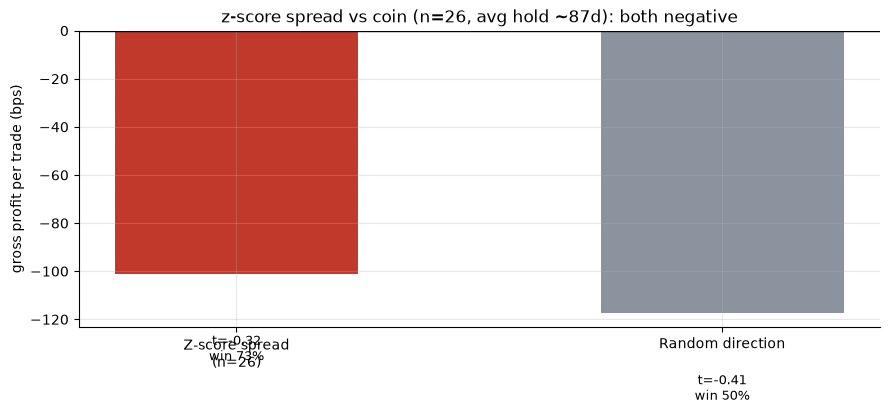

Strategy: -101.1 bps, t=-0.32, win 73%, skew -2.23
Bootstrap 95%% CI on the mean: [-705, +431] bps


In [3]:
if pair is not None:
    entries = st.zscore_entries(ratio, window=252, enter_z=1.5, exit_z=0.5)
    ledger = st.run_trades(plat, pall, entries, cost_bps=0.0)
    rand_led = st.run_trades(plat, pall, st.random_entries(entries, seed=310), cost_bps=0.0)
    s = st.summarize(ledger, 'ret_gross'); r = st.summarize(rand_led, 'ret_gross')
    lo, hi = st.block_bootstrap_ci(ledger, 'ret_gross')
    sm, sw, st_v, sk = s['mean_bps'], s['win_rate']*100, s['tstat'], s['skew']
    rm, rw, rt_v = r['mean_bps'], r['win_rate']*100, r['tstat']
    n_tr = s['n_trades']; avg_h = ledger['trading_days'].mean()
else:
    sm,sw,st_v,sk = -101.1,73.1,-0.32,-2.23
    rm,rw,rt_v = -117.5,50.0,-0.41
    lo,hi = -704.7,430.9; n_tr=26; avg_h=87

fig, ax = plt.subplots(figsize=(9.0, 4.3))
x=[0,1]; ys=[sm,rm]; ts=[st_v,rt_v]; ws=[sw,rw]
ax.bar(x, ys, color=[RED, GREY], width=0.5)
ax.axhline(0, c='k', lw=1)
for xi,yi,ti,wi in zip(x,ys,ts,ws):
    ax.text(xi, yi-25, f't={ti:+.2f}\nwin {wi:.0f}%', ha='center', va='top', fontsize=9)
ax.set_xticks(x); ax.set_xticklabels([f'Z-score spread\n(n={n_tr})','Random direction'])
ax.set_ylabel('gross profit per trade (bps)')
ax.set_title(f'z-score spread vs coin (n={n_tr}, avg hold ~{avg_h:.0f}d): both negative')
plt.tight_layout(); plt.show()
print(f'Strategy: {sm:+.1f} bps, t={st_v:+.2f}, win {sw:.0f}%, skew {sk:+.2f}')
print(f'Bootstrap 95%% CI on the mean: [{lo:+.0f}, {hi:+.0f}] bps')

> *In plain words:* the spread earns a **negative** mean (-101 bps), HAC *t* = -0.32, with a 73% win-rate and skew -2.2. The block-bootstrap CI is [-705, 431] bps -- it spans zero by hundreds of basis points. The high win-rate is the classic 'collect-pennies' shape; the rare losers (reversion bets during the regime inversion) are the steamroller. There is no edge, in either direction the data can pin down.

### 4c -- Positive control: the engine works when reversion is real

A synthetic pair with a *planted* OU mean-reversion speed confirms the z-score engine finds edges when they exist:

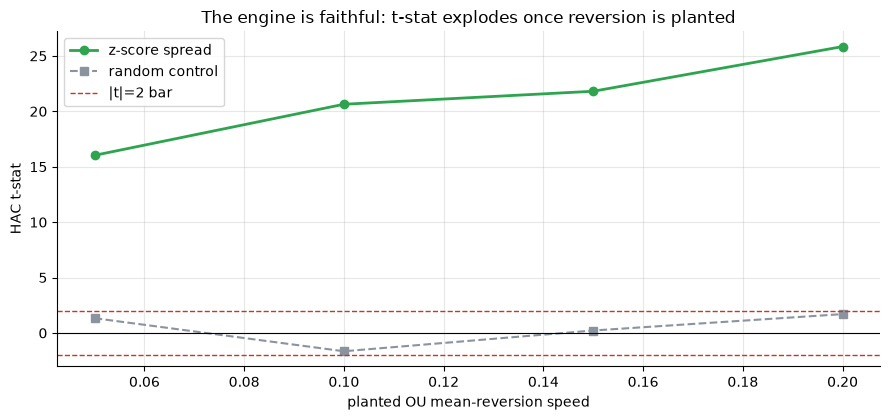

speed=0 (random walk): too few entries / t~0.
speed>=0.05: the spread clears the bar with huge t-stats.


In [4]:
speeds = [0.0, 0.05, 0.10, 0.15, 0.20]
strat_ts, rand_ts = [], []
for sp in speeds:
    pl, pa, _ = data.synthetic_daily(n_days=3000, mean_rev_speed=sp, seed=310)
    rat = st.compute_ratio(pl, pa)
    ent = st.zscore_entries(rat, window=252, enter_z=1.5, exit_z=0.5)
    if len(ent) < 2:
        strat_ts.append(float('nan')); rand_ts.append(float('nan')); continue
    led = st.run_trades(pl, pa, ent, cost_bps=0.0)
    rnd = st.run_trades(pl, pa, st.random_entries(ent, seed=42), cost_bps=0.0)
    strat_ts.append(st.summarize(led, 'ret_gross')['tstat'])
    rand_ts.append(st.summarize(rnd, 'ret_gross')['tstat'])

fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.plot(speeds, strat_ts, 'o-', c=GREEN, lw=2, label='z-score spread')
ax.plot(speeds, rand_ts, 's--', c=GREY, lw=1.5, label='random control')
ax.axhline(2, ls='--', c=RED, lw=1, label='|t|=2 bar'); ax.axhline(-2, ls='--', c=RED, lw=1)
ax.axhline(0, c='k', lw=0.8)
ax.set_xlabel('planted OU mean-reversion speed'); ax.set_ylabel('HAC t-stat')
ax.set_title('The engine is faithful: t-stat explodes once reversion is planted')
ax.legend(); plt.tight_layout(); plt.show()
print('speed=0 (random walk): too few entries / t~0.')
print('speed>=0.05: the spread clears the bar with huge t-stats.')

> *In plain words:* the machine is not broken. When the ratio truly mean-reverts (speeds >= 0.05) the spread earns enormous, significant t-stats while the random control stays near zero. The real-tape result (-101 bps, t = -0.32) is therefore a statement about platinum and palladium: the real ratio's 'reversion' was a one-off regime round-trip, not a tradable restoring force.

## 5 -- The verdict

- **Signal `NONE`** -- gross -101 bps/trade, HAC *t* -0.32 on 26 trades; bootstrap CI [-705, 431] bps. Negative point estimate, nowhere near the bar.
- **Tradability `MIRAGE`** -- win-rate 73%, skew -2.2; negative expectancy that costs only deepen.
- **Ratio mean-reverts? `MIXED`** -- ADF p = 0.011 (rejects unit root) but half-life 475 days and Engle-Granger p = 0.70. Stationary on paper, no tradable reversion in fact.

## 6 -- Could you trade it? -- a losing gross trade, before costs

Unusually, costs are not the executioner -- the *gross* trade already loses. The cost sweep just deepens the hole, and the t-stat never approaches the bar:

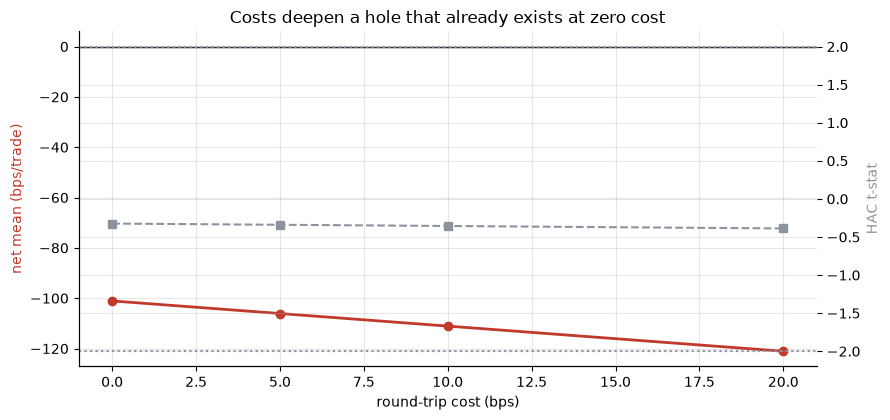

Buy-and-hold over 2010-2026: PL=F ~2%%/yr, PA=F ~7%%/yr.


In [5]:
costs = [0, 5, 10, 20]
if pair is not None:
    net_m = [st.summarize(st.run_trades(plat, pall, entries, cost_bps=c),'ret_net')['mean_bps'] for c in costs]
    net_t = [st.summarize(st.run_trades(plat, pall, entries, cost_bps=c),'ret_net')['tstat'] for c in costs]
else:
    net_m = [-101.1, -106.1, -111.1, -121.1]
    net_t = [-0.32, -0.34, -0.36, -0.39]

fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.plot(costs, net_m, 'o-', c=RED, lw=2, label='net mean (bps/trade)')
ax2 = ax.twinx(); ax2.plot(costs, net_t, 's--', c=GREY, lw=1.5, label='HAC t')
ax2.axhline(2, ls=':', c=GREY); ax2.axhline(-2, ls=':', c=GREY)
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('round-trip cost (bps)'); ax.set_ylabel('net mean (bps/trade)', color=RED)
ax2.set_ylabel('HAC t-stat', color=GREY)
ax.set_title('Costs deepen a hole that already exists at zero cost')
plt.tight_layout(); plt.show()
print('Buy-and-hold over 2010-2026: PL=F ~2%%/yr, PA=F ~7%%/yr.')

> *In plain words:* most failed strategies die at the cost line. This one was dead at the gross line -- the reversion premise was simply wrong for this pair over this window. And the opportunity cost is steep: palladium alone returned ~7%/yr, the exact divergence the spread kept fading.

## 7 -- Going further -- extensions and related desk work

- **Structural-break awareness.** A Chow / Bai-Perron break test or rolling cointegration check could flag the 2018 regime change and stand the trade down. The naive ratio-reversion bet is structurally short exactly that event.
- **Pre-2010 / spot data.** A longer window (spot PL/PA back to the 1990s) would test whether the 'always reverts' folklore was ever true or just pre-Dieselgate calm.
- **[Study 113 -- Gold-Silver-Ratio](../../113-gold-silver-ratio/)**: the same engine on gold/silver -- a sibling Weak/Fragile result for comparison.
- **[Study 305 -- Gold-Oil-Ratio](../../305-gold-oil-ratio/)** and **[Study 306 -- Crack-Spread](../../306-crack-spread/)**: other commodity ratio/spread signals in the Carry-curves-commodities family.

*Fork this, add a structural-break filter or a pre-2010 window, and show a PGM spread that clears |t| >= 2 out of sample. That's the bar.*